In [299]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score


X_train =pd.read_csv("../data/X_train_6ZIKlTY.csv")

print(X_train.shape)
print(X_train.head())
print("=== Valeurs manquantes ===")
print(X_train.isnull().sum())


(55603, 12)
   Index patient_id cohort  sexM    gene  age_at_diagnosis   age   ledd  \
0      0   IPLP5212      A     0  LRRK2+              48.5  52.1  607.0   
1      1   IPLP5212      A     0  LRRK2+              48.5  53.0  666.0   
2      2   IPLP5212      A     0  LRRK2+              48.5  53.9  717.0   
3      3   IPLP5212      A     0  LRRK2+              48.5  54.8  770.0   
4      4   IPLP5212      A     0  LRRK2+              48.5  56.9  885.0   

   time_since_intake_on  time_since_intake_off    on   off  
0                   1.9                    NaN   7.0   NaN  
1                   1.9                   17.6  12.0  44.0  
2                   1.2                    NaN   6.0   NaN  
3                   1.5                    NaN  11.0   NaN  
4                   0.3                    NaN  24.0   NaN  
=== Valeurs manquantes ===
Index                        0
patient_id                   0
cohort                       0
sexM                         0
gene                

In [300]:
colonnes = ["age_at_diagnosis", "ledd", "time_since_intake_on", 
            "time_since_intake_off", "time_since_diagnosis", 
            "on", "off", "mean_on", "mean_off", "mean_ledd",
            "dose_per_year", "on_off_ratio", "age_diagnosis_interaction"]

In [301]:
print("=== Types des colonnes ===")
print(X_train.dtypes)

=== Types des colonnes ===
Index                      int64
patient_id                object
cohort                    object
sexM                       int64
gene                      object
age_at_diagnosis         float64
age                      float64
ledd                     float64
time_since_intake_on     float64
time_since_intake_off    float64
on                       float64
off                      float64
dtype: object


              Index        target
count  55603.000000  55603.000000
mean   27801.000000     37.331606
std    16051.347846     16.504326
min        0.000000      0.000000
25%    13900.500000     25.400000
50%    27801.000000     37.100000
75%    41701.500000     49.200000
max    55602.000000    109.500000


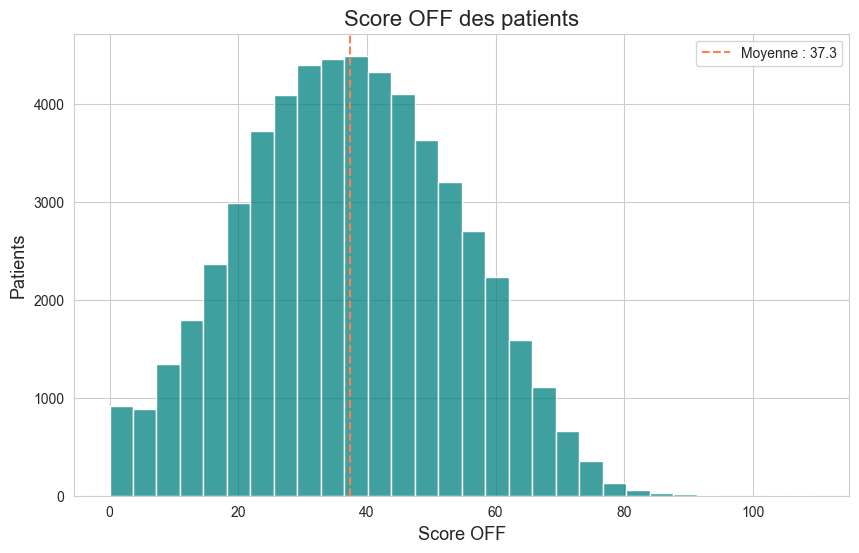

In [302]:
y_train =pd.read_csv("../data/y_train_lXj6X5y.csv")
print(y_train.describe())


moyenne = y_train["target"].mean()
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(y_train["target"], color = "teal" , bins=30)
plt.title("Score OFF des patients", fontsize=16)
plt.xlabel("Score OFF", fontsize=13)
plt.ylabel("Patients", fontsize=13)
plt.axvline(x=moyenne, color="coral", linestyle="--", label=f"Moyenne : {moyenne:.1f}")
plt.legend()
plt.show()


In [303]:
X_test=pd.read_csv("../data/X_test_oiZ2ukx.csv")

print(X_test.shape)
print(X_test.dtypes)
print(set(X_train.columns) - set(X_test.columns))
print(set(X_test.columns) - set(X_train.columns))


(23672, 13)
Index                      int64
patient_id                object
cohort                    object
sexM                       int64
gene                      object
age_at_diagnosis         float64
age                      float64
ledd                     float64
time_since_intake_on     float64
time_since_intake_off    float64
on                       float64
off                      float64
time_since_diagnosis     float64
dtype: object
set()
{'time_since_diagnosis'}


In [304]:
X_train["time_since_diagnosis"] = X_train["age"] - X_train["age_at_diagnosis"]

le_cohort = LabelEncoder()
le_gene = LabelEncoder()

X_train["cohort"] = le_cohort.fit_transform(X_train["cohort"])
X_test["cohort"] = le_cohort.transform(X_test["cohort"])

X_train["gene"] = X_train["gene"].fillna("Unknown")
X_train["gene"] = le_gene.fit_transform(X_train["gene"])

X_test["gene"] = X_test["gene"].fillna("Unknown")
X_test["gene"] = le_gene.transform(X_test["gene"])

cohort_stats = X_train.groupby("cohort").agg(
    mean_on=("on", "mean"),
    mean_off=("off", "mean"),
    mean_ledd=("ledd", "mean"),
    nb_visites=("age", "count")
).reset_index()

X_train = X_train.merge(cohort_stats, on="cohort", how="left")
X_test = X_test.merge(cohort_stats, on="cohort", how="left")

X_train["dose_per_year"] = X_train["ledd"] / (X_train["time_since_diagnosis"] + 1)
X_test["dose_per_year"]  = X_test["ledd"]  / (X_test["time_since_diagnosis"] + 1)

X_train["on_off_ratio"] = X_train["on"] / (X_train["off"] + 1)
X_test["on_off_ratio"]  = X_test["on"]  / (X_test["off"] + 1)

X_train["age_diagnosis_interaction"] = X_train["age"] * X_train["time_since_diagnosis"]
X_test["age_diagnosis_interaction"]  = X_test["age"]  * X_test["time_since_diagnosis"]


X_train = X_train.drop(columns=['Index'])
X_test = X_test.drop(columns=['Index'])
X_train = X_train.drop(columns=['patient_id'])
X_test = X_test.drop(columns=['patient_id'])


In [305]:
X_train["a_score_off_mesure"] = X_train["time_since_intake_off"].isnull().astype(int)
X_test["a_score_off_mesure"]  = X_test["time_since_intake_off"].isnull().astype(int)

In [306]:
imputer = SimpleImputer(strategy="median")
colonnes = ["age_at_diagnosis", "ledd", "time_since_intake_on", 
            "time_since_intake_off", "time_since_diagnosis", 
            "on", "off", "dose_per_year", "on_off_ratio", 
            "age_diagnosis_interaction"]
X_train[colonnes] = imputer.fit_transform(X_train[colonnes])
X_test[colonnes] = imputer.transform(X_test[colonnes])

X=X_train
y= y_train["target"]

print("Manquants X_train:", X_train.isnull().sum().sum())
print("Manquants X_test:", X_test.isnull().sum().sum())
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Manquants X_train: 0
Manquants X_test: 0
Series([], dtype: int64)
Series([], dtype: int64)


In [307]:
print("Manquants X_train:", X_train.isnull().sum().sum())
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

Manquants X_train: 0
Series([], dtype: int64)


In [308]:
X_train_val , X_val , y_train_val , y_val = train_test_split(
    X , y ,
    test_size=0.2 ,
    random_state= 42
)

### Modèle 1 : Linear Regression
Ce modèle sert de baseline...

In [309]:
model = LinearRegression()
model.fit(X_train_val, y_train_val)
y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)

RMSE: 9.671085425435258


### Modèle 2 : Random Forest
Un ensemble de centaines d'arbres...

In [310]:
model_rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
model_rf.fit(X_train_val, y_train_val)
y_pred = model_rf.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)

RMSE: 7.41373003342081


### Modèle 3 : XGBoost
Gradient boosting


In [311]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train_val, y_train_val)
y_pred = model_xgb.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE:", rmse)

RMSE: 7.165071525886232


In [312]:
model_xgb2 = XGBRegressor()
model_xgb2.fit(X, y)
y_pred = model_xgb2.predict(X_test)

submission = pd.DataFrame({
    "Index": X_test.index,
    "target": y_pred
})
submission.to_csv("../data/submission.csv", index=False)

In [313]:
model_cv = XGBRegressor(random_state=42)

scores = cross_val_score(
    model_cv,
    X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print("RMSE par fold :", rmse_scores)
print("RMSE moyen    :", rmse_scores.mean())
print("Écart-type    :", rmse_scores.std())

RMSE par fold : [7.35489819 7.5727935  7.64262357 7.42729609 7.54897756]
RMSE moyen    : 7.509317780903167
Écart-type    : 0.10387056212546276


In [314]:
model_tuned = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

scores = cross_val_score(
    model_tuned,
    X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print("RMSE par fold :", rmse_scores)
print("RMSE moyen    :", rmse_scores.mean())
print("Écart-type    :", rmse_scores.std())

RMSE par fold : [7.20416721 7.42087775 7.50402181 7.27533087 7.42834926]
RMSE moyen    : 7.366549380612102
Écart-type    : 0.10987106019812894


In [315]:
model_tuned.fit(X, y)
y_pred = model_tuned.predict(X_test)

submissionx = pd.DataFrame({ 
    "Index": X_test.index,     
    "target": y_pred
})
submissionx.to_csv("../data/submissionx.csv", index=False)